In [1]:
import networkx as nx

<h4> An example directed graph

In [2]:
G1 = nx.DiGraph() 

In [3]:
G1.add_nodes_from([0, 1, 2])
G1.add_edges_from([(0,1),(1,0),(0,2),(2,1)])

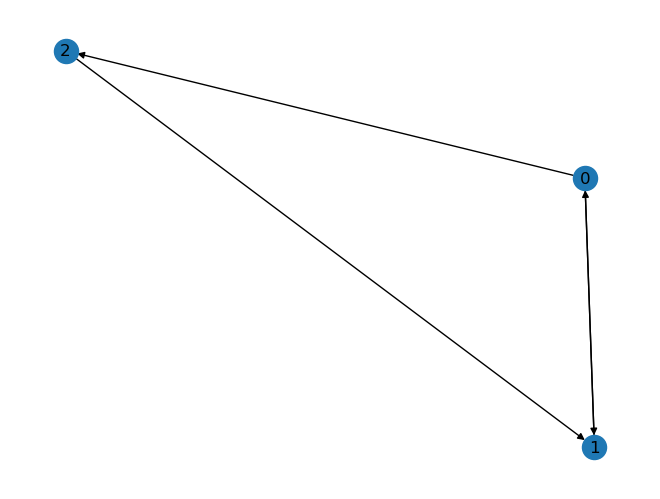

In [4]:
nx.draw(G1, with_labels=True)

In [5]:
G1.nodes

NodeView((0, 1, 2))

In [6]:
G1.edges

OutEdgeView([(0, 1), (0, 2), (1, 0), (2, 1)])

In [7]:
G1.degree

DiDegreeView({0: 3, 1: 3, 2: 2})

<h4> An example undirected graph

In [8]:
G2 = nx.Graph() 

In [9]:
G2.add_nodes_from([0, 1, 2])
G2.add_edges_from([(0,1),(0,2)])

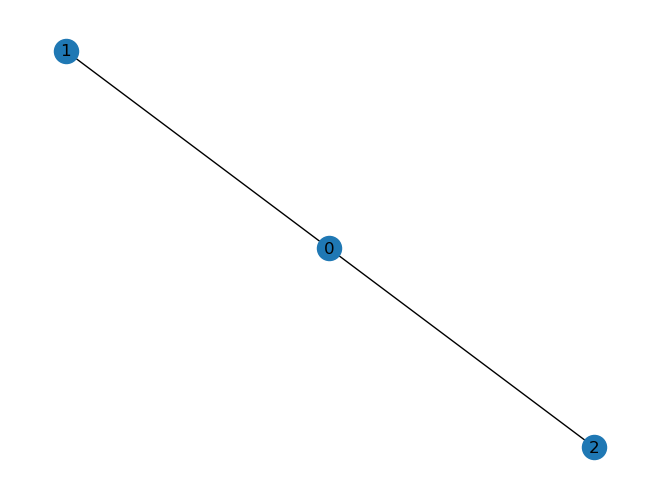

In [10]:
nx.draw(G2, with_labels=True)

In [11]:
G2.degree

DegreeView({0: 2, 1: 1, 2: 1})

<h4> Modularity

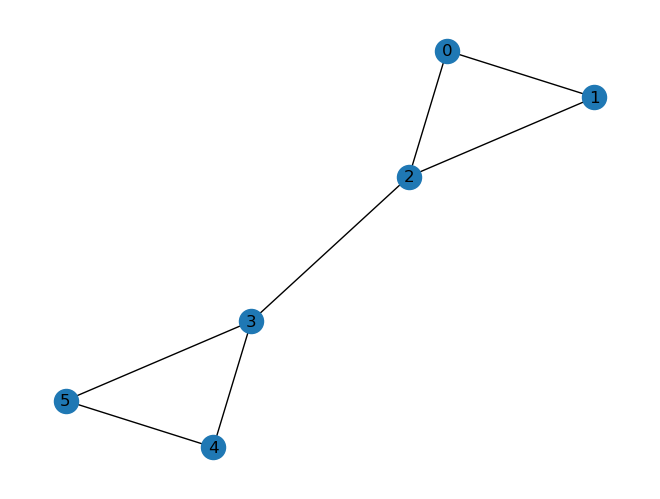

In [12]:
G = nx.barbell_graph(3, 0)
nx.draw(G, with_labels=True)

In [13]:
nx.community.modularity(G, [{0, 1, 2,3, 4, 5}]) #one community; modularity = 0

1.1102230246251565e-16

In [14]:
nx.community.modularity(G, [{0, 1, 2}, {3, 4, 5}]) #two communities: modularity = 0.357

0.35714285714285715

<h4> Exercise: Recalculate these value using the expression for $Q$.

In [20]:
m = 7
Q = 0
for i in range(6):
    for j in range(6):
        if (i,j) in G.edges:
            Q += (1-G.degree[i]*G.degree[j]/(2*m))
        else:
            Q += (0-G.degree[i]*G.degree[j]/(2*m))
            
Q = (1/(2*m))*Q
print(Q)

-1.586032892321652e-17


In [21]:
m = 7
Q = 0
for i in range(3):
    for j in range(3):
        if (i,j) in G.edges:
            Q += (1-G.degree[i]*G.degree[j]/(2*m))
        else:
            Q += (0-G.degree[i]*G.degree[j]/(2*m))

for i in range(3,6):
    for j in range(3,6):
        if (i,j) in G.edges:
            Q += (1-G.degree[i]*G.degree[j]/(2*m))
        else:
            Q += (0-G.degree[i]*G.degree[j]/(2*m))
            
            
Q = (1/(2*m))*Q
print(Q)

0.35714285714285704


<h4> Graphs with weighted edges

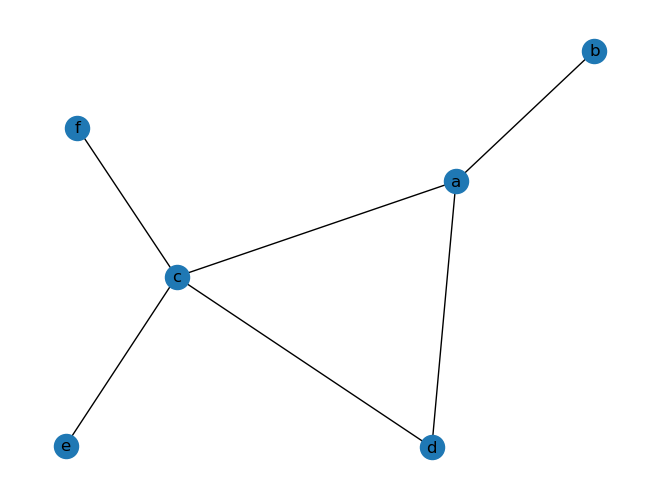

In [15]:
G = nx.Graph()

G.add_edge("a", "b", weight=0.6)
G.add_edge("a", "c", weight=0.2)
G.add_edge("c", "d", weight=0.1)
G.add_edge("c", "e", weight=0.7)
G.add_edge("c", "f", weight=0.9)
G.add_edge("a", "d", weight=0.3)

nx.draw(G, with_labels=True)

<h4> Louvain communities

Grupa 0: [0, 1, 2]
Grupa 1: [3, 4, 5]


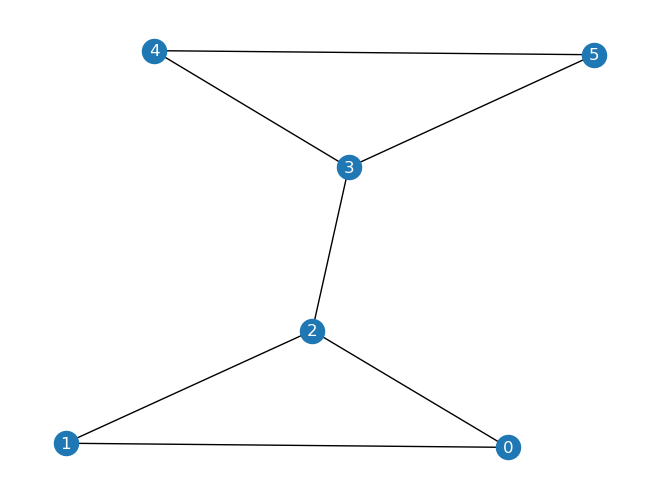

In [18]:
import networkx as nx
from networkx.algorithms import community

G = nx.barbell_graph(3, 0)
nx.draw(G,with_labels = True, font_color = 'white')

#wykrywanie grup (np. metoda greedy modularity)
communities = community.greedy_modularity_communities(G)

for i, c in enumerate(communities):
    print(f"Grupa {i}: {list(c)}")

<h4> Exercise: Open $scRNAdata.csv$ file. Rows are genes, columns are cells.

    
- How many cells and genes are considered?
- Standarize the data and apply PCA with $k=2$.
- Plot the PCA1 vs PCA2 components. Do you notice some groups?
- Build a graph on cells, where the edge weight is defined as $\exp(-||c_i-c_j||)$.
- Find the best partition of the graph.
- Plot the PCA1 vs PCA2 components once again. Colour the data points according to partition. 

In [19]:
import pandas as pd

d = pd.read_csv('scRNAdata.csv', sep=',', index_col=0)
d.head()

,cell0,cell1,cell2,cell3,cell4,cell5,cell6,cell7,cell8,cell9,...,cell360,cell361,cell362,cell363,cell364,cell365,cell366,cell367,cell368,cell369
0,1404.0,1382.0,10845.0,414.0,3698.0,1846.0,2452.0,1128.0,7309.0,2544.0,...,9415.0,181.0,1167.0,502.0,4704.0,10165.0,6416.0,4530.0,470.0,556.0
1,10445.0,739.0,3675.0,209.0,3212.0,7308.0,859.0,7577.0,2475.0,1178.0,...,6108.0,4.0,2742.0,6336.0,651.0,876.0,2357.0,2975.0,197.0,3690.0
2,7137.0,959.0,260.0,6356.0,6157.0,6698.0,732.0,58.0,4493.0,6539.0,...,7151.0,2700.0,4111.0,6996.0,3825.0,443.0,1628.0,2004.0,1150.0,7836.0
3,190.0,1264.0,8449.0,3548.0,4312.0,3637.0,3513.0,1649.0,1838.0,1792.0,...,4036.0,6749.0,2175.0,1701.0,87.0,4381.0,1326.0,3197.0,3426.0,378.0
4,1432.0,1439.0,534.0,1314.0,6166.0,5702.0,5279.0,1291.0,3491.0,2176.0,...,4022.0,7837.0,328.0,2230.0,2295.0,1679.0,1066.0,6951.0,3684.0,4929.0


In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles

In [21]:
#Standarization
stdsc = StandardScaler()
X = stdsc.fit_transform(d)

#PCA
pca = PCA(2)
X2 = pca.fit_transform(X.T) 
print(X2.shape)

(370, 2)


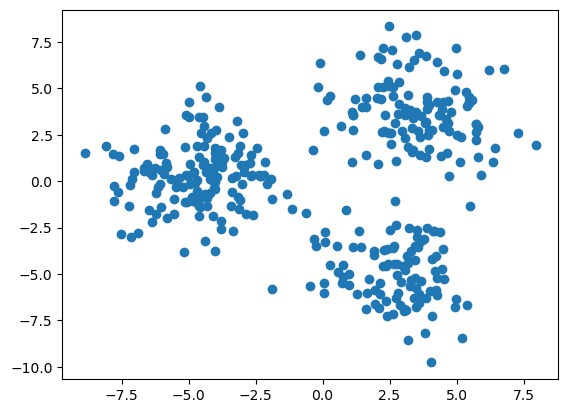

In [22]:
plt.scatter(X2[:,0], X2[:,1]) #plot PC1/PC2
plt.show()

In [37]:
#build a graph
G = nx.Graph()
for i in range(370):
    for j in range(370):
        if i != j:
            d = np.exp(-np.linalg.norm(X2[i]-X2[j]))
            if d>0.2:
                G.add_edge(i, j, weight=d)          

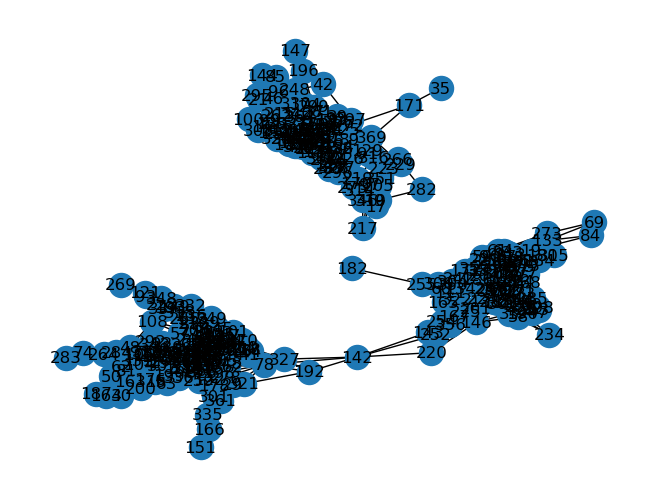

In [38]:
nx.draw(G, with_labels=True)

In [39]:
partition = community.greedy_modularity_communities(G)
print(partition)

[frozenset({4, 10, 12, 14, 15, 23, 27, 29, 30, 31, 32, 36, 38, 41, 43, 45, 48, 50, 51, 54, 56, 57, 62, 63, 67, 68, 70, 72, 74, 75, 78, 79, 80, 81, 92, 93, 94, 98, 101, 102, 103, 104, 105, 108, 109, 110, 113, 118, 121, 122, 124, 131, 132, 136, 137, 145, 148, 149, 150, 151, 153, 155, 157, 160, 162, 163, 164, 166, 176, 178, 181, 183, 185, 187, 189, 191, 192, 193, 195, 198, 199, 200, 202, 203, 208, 209, 210, 211, 216, 227, 228, 231, 235, 236, 240, 241, 244, 245, 249, 253, 257, 259, 260, 261, 264, 265, 269, 270, 276, 278, 279, 283, 284, 286, 288, 289, 290, 292, 293, 301, 306, 307, 311, 313, 317, 318, 320, 321, 324, 326, 327, 329, 331, 332, 334, 335, 336, 337, 338, 343, 348, 349, 352, 358, 361, 362, 365, 367, 368}), frozenset({1, 3, 262, 7, 6, 9, 266, 263, 267, 11, 13, 272, 17, 16, 275, 20, 21, 277, 281, 282, 28, 287, 35, 37, 294, 295, 39, 297, 42, 296, 299, 44, 46, 302, 47, 49, 308, 52, 310, 309, 55, 314, 316, 319, 323, 325, 71, 328, 330, 76, 340, 85, 341, 86, 342, 89, 346, 345, 91, 347, 35